# California Houses Regression

### Step 1: Import Libraries and Load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# === Step 1: Load dataset ===
df = pd.read_csv(r'C:\Users\me\Desktop\Engineering_Term _7\Machine_Learning\Assignment1\California_Regression\California_Houses.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\me\\Desktop\\Engineering_Term _7\\Machine_Learning\\Assignment1\\California_Regression\\California_Houses.csv'

### Step 2a: Define features and target 

In [ ]:

X = df.drop('Median_House_Value', axis=1)
y = df['Median_House_Value']

### Step 2b: Spliting the data set

In [ ]:
print("\nSplitting dataset: 70% train, 15% validation, 15% test")
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=203)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.17643, random_state=203)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Splitting dataset: 70% train, 15% validation, 15% test
Training set size: 14448
Validation set size: 3096
Test set size: 3096


### Step 2c: Scaling features and adding bias term

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

### Step 3: Manual Linear Regression
- The Linear regression manual equation finds weights that minimize the squared error by computing optimal coefficients.
- The Linear regression gradient descent updates weights iteratively to reduce the loss.


In [ ]:
def linear_regression_normal_eq(X, y):
   
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return w

def linear_regression_gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
  
    m, n = X.shape
    w = np.zeros(n)
    cost_history = []
    
    for i in range(n_iterations):
        
        y_pred = X @ w
        
        gradient = (1/m) * X.T @ (y_pred - y)
        
        w = w - learning_rate * gradient
        
        cost = (1/(2*m)) * np.sum((y_pred - y)**2)
        cost_history.append(cost)
        
        if (i+1) % 100 == 0:
            print(f"  Iteration {i+1}/{n_iterations}, Cost: {cost:.4f}")
    
    return w, cost_history

### Step 4a: Train & Evaluate Manual Linear Regression using Normal Equation
After training the model using linear regression normal equation and computing weights, we make predictions for y.
The following outputs for the Normal equation are then displayed:
- Mean Squared Error
- Mean Absolute Error
- Variance or R2 Score

In [ ]:
print("\nMethod 1: Normal Equation (Closed-form solution)")
w_linear_normal = linear_regression_normal_eq(X_train_b, y_train)

y_train_pred_linear = X_train_b @ w_linear_normal


mse_train_linear = mean_squared_error(y_train, y_train_pred_linear)
mae_train_linear = mean_absolute_error(y_train, y_train_pred_linear)
r2_train_linear = r2_score(y_train, y_train_pred_linear)

print(f"Training MSE: {mse_train_linear:.4f}, MAE: {mae_train_linear:.4f}, R²: {r2_train_linear:.4f}")


Method 1: Normal Equation (Closed-form solution)
Training MSE: 4782569775.1896, MAE: 50208.4066, R²: 0.6415


### Step 4b: Using Gradient Descent
The linear regression gradient descent sets first all weights to zero and then iteratively updates them.
The following outputs for the Gradient Descent are then displayed:
- Mean Squared Error
- Mean Absolute Error
- Variance or R2 Score


In [ ]:
print("\nMethod 2: Gradient Descent (Iterative optimization)")
w_linear_gd, cost_history_linear = linear_regression_gradient_descent(
    X_train_b, y_train, learning_rate=0.01, n_iterations=1000
)

y_train_pred_linear_gd = X_train_b @ w_linear_gd

mse_train_linear_gd = mean_squared_error(y_train, y_train_pred_linear_gd)
mae_train_linear_gd = mean_absolute_error(y_train, y_train_pred_linear_gd)
r2_train_linear_gd = r2_score(y_train, y_train_pred_linear_gd)
print(f"Training MSE: {mse_train_linear_gd:.4f}, MAE: {mae_train_linear_gd:.4f}, R²: {r2_train_linear_gd:.4f}")
print(f"Weights difference (Normal Eq vs GD): {np.linalg.norm(w_linear_normal - w_linear_gd):.6f}")


Method 2: Gradient Descent (Iterative optimization)
  Iteration 100/1000, Cost: 5946095294.5044
  Iteration 200/1000, Cost: 3054099472.8795
  Iteration 300/1000, Cost: 2644972224.7974
  Iteration 400/1000, Cost: 2565592092.4611
  Iteration 500/1000, Cost: 2535635720.4765
  Iteration 600/1000, Cost: 2516423727.0116
  Iteration 700/1000, Cost: 2501694932.8792
  Iteration 800/1000, Cost: 2489868338.8302
  Iteration 900/1000, Cost: 2480204057.4373
  Iteration 1000/1000, Cost: 2472213352.1831
Training MSE: 4944281199.1176, MAE: 51655.5690, R²: 0.6294
Weights difference (Normal Eq vs GD): 134299.337406


### Step 5: Ridge Regression
It shrinks weights to improve generalization by adding L2 penalty 


In [ ]:
def ridge_regression_normal_eq(X, y, alpha):
    n = X.shape[1]
    I = np.eye(n)
    I[0, 0] = 0 
    w = np.linalg.inv(X.T @ X + alpha * I) @ X.T @ y
    return w

### Step 6: Lasso Regression
It uses L1 penalty and coordinate descent to optimize weights.
Unlike Ridge, Lasso Regression also can set some features to 0 implementing **feature selection**.
This selects only the most relevant features.

In [ ]:
def soft_thresholding(rho, alpha):
    if rho < -alpha:
        return rho + alpha
    elif rho > alpha:
        return rho - alpha
    else:
        return 0.0

def lasso_coordinate_descent(X, y, alpha, num_iters=1000):
    m, n = X.shape
    w = np.zeros(n)
    
    for _ in range(num_iters):
        for j in range(n):
            X_j = X[:, j]
            residual = y - X @ w + w[j] * X_j
            rho = X_j.T @ residual
            if j == 0:
                # Don't regularize the bias term
                w[j] = rho / (X_j.T @ X_j)
            else:
                w[j] = soft_thresholding(rho, alpha) / (X_j.T @ X_j)
    
    return w 

### Step 7: Testing and Training Lasso and Ridge over Multiple Alphas
The output will be the MSE accuracy, MAE and R^2 for every alpha

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_mses, ridge_maes, ridge_r2s = [], [], []
lasso_mses, lasso_maes, lasso_r2s = [], [], []
lowest_mse_ridge = float('inf')
best_alpha_ridge = None
lowest_mse_lasso = float('inf')
best_alpha_lasso = None

print("\n🔁 Training Ridge and Lasso (Manual) over different alphas:\n")

for alpha in alphas:
    # === Ridge ===
    w_ridge = ridge_regression_normal_eq(X_train_b, y_train, alpha)
    y_pred_ridge = X_train_b @ w_ridge
    ridge_mses.append(mean_squared_error(y_train, y_pred_ridge))
    ridge_maes.append(mean_absolute_error(y_train, y_pred_ridge))
    ridge_r2s.append(r2_score(y_train, y_pred_ridge))
    if ridge_mses[-1] < lowest_mse_ridge:
        lowest_mse_ridge = ridge_mses[-1]
        best_alpha_ridge = alpha

    # === Lasso ===
    w_lasso = lasso_coordinate_descent(X_train_b, y_train, alpha, num_iters=1000)
    y_pred_lasso = X_train_b @ w_lasso
    lasso_mses.append(mean_squared_error(y_train, y_pred_lasso))
    lasso_maes.append(mean_absolute_error(y_train, y_pred_lasso))
    lasso_r2s.append(r2_score(y_train, y_pred_lasso))
    if lasso_mses[-1] < lowest_mse_lasso:
        lowest_mse_lasso = lasso_mses[-1]
        best_alpha_lasso = alpha

    # Print for each alpha
    print(f"Alpha = {alpha}")
    print(f"  Ridge  → MSE: {ridge_mses[-1]:.4f}, MAE: {ridge_maes[-1]:.4f}, R²: {ridge_r2s[-1]:.4f}")
    print(f"  Lasso  → MSE: {lasso_mses[-1]:.4f}, MAE: {lasso_maes[-1]:.4f}, R²: {lasso_r2s[-1]:.4f}\n")


🔁 Training Ridge and Lasso (Manual) over different alphas:

Alpha = 0.001
  Ridge  → MSE: 4782569775.2206, MAE: 50208.4093, R²: 0.6415
  Lasso  → MSE: 4782572428.0800, MAE: 50208.4556, R²: 0.6415

Alpha = 0.01
  Ridge  → MSE: 4782569778.2873, MAE: 50208.4330, R²: 0.6415
  Lasso  → MSE: 4782572428.0821, MAE: 50208.4556, R²: 0.6415

Alpha = 0.1
  Ridge  → MSE: 4782570083.3852, MAE: 50208.6696, R²: 0.6415
  Lasso  → MSE: 4782572428.1033, MAE: 50208.4556, R²: 0.6415

Alpha = 1
  Ridge  → MSE: 4782599084.5064, MAE: 50211.1136, R²: 0.6415
  Lasso  → MSE: 4782572428.3152, MAE: 50208.4557, R²: 0.6415

Alpha = 10
  Ridge  → MSE: 4784468089.1735, MAE: 50247.8820, R²: 0.6414
  Lasso  → MSE: 4782572430.4347, MAE: 50208.4560, R²: 0.6415

Alpha = 100
  Ridge  → MSE: 4811014074.9416, MAE: 50563.0903, R²: 0.6394
  Lasso  → MSE: 4782572451.6923, MAE: 50208.4588, R²: 0.6415



### Step 8: Plot Alpha vs Training MSE

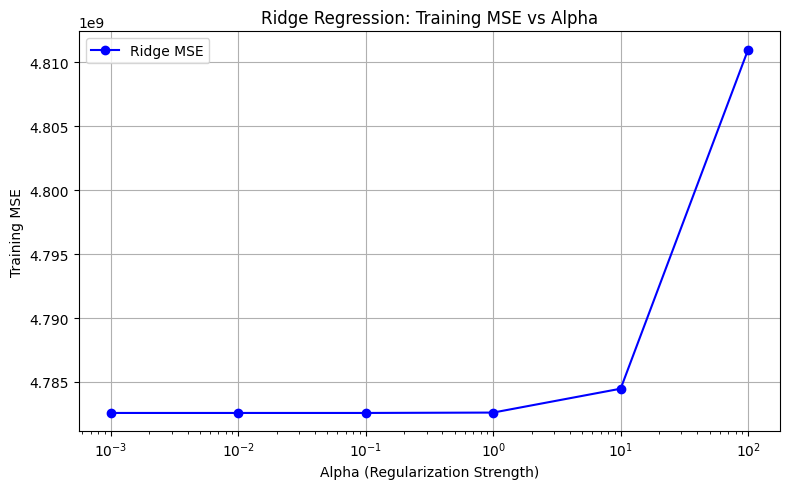

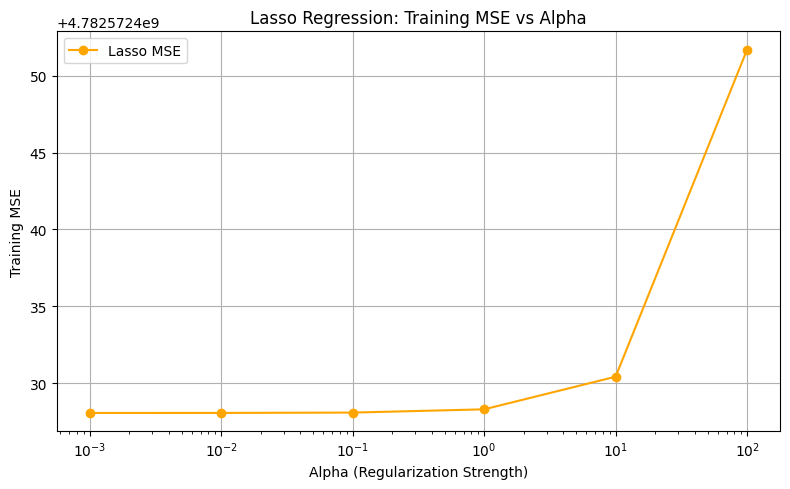

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_mses, marker='o', label='Ridge MSE', color='blue')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Training MSE')
plt.title('Ridge Regression: Training MSE vs Alpha')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# === Plot: Lasso Regression - MSE vs Alpha ===
plt.figure(figsize=(8, 5))
plt.plot(alphas, lasso_mses, marker='o', label='Lasso MSE', color='orange')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Training MSE')
plt.title('Lasso Regression: Training MSE vs Alpha')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Step 9a: Skikit Linear Regression

In [ ]:
models = {}
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_val_scaled)
lr_mse = mean_squared_error(y_val, lr_pred)
models["Linear Regression"] = lr

### Step 9b: Skikit Ridge Regression


In [ ]:
ridge_alphas = [0.001, 1, 10, 100, 1000, 10000]
ridge_mses = []
best_ridge = None
best_ridge_mse = float('inf')
best_ridge_alpha = None

for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    preds = ridge.predict(X_val_scaled)
    mse = mean_squared_error(y_val, preds)
    ridge_mses.append(mse)
    if mse < best_ridge_mse:
        best_ridge = ridge
        best_ridge_mse = mse
        best_ridge_alpha = alpha

models[f"Ridge Regression (alpha={best_ridge_alpha})"] = best_ridge

### Step 9c: Skikit Lasso Regression


In [ ]:
lasso_alphas = [0.001, 1, 10, 100, 1000, 10000]
lasso_mses = []
best_lasso = None
best_lasso_mse = float('inf')
best_lasso_alpha = None

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    preds = lasso.predict(X_val_scaled)
    mse = mean_squared_error(y_val, preds)
    lasso_mses.append(mse)
    if mse < best_lasso_mse:
        best_lasso = lasso
        best_lasso_mse = mse
        best_lasso_alpha = alpha

models[f"Lasso Regression (alpha={best_lasso_alpha})"] = best_lasso

### Step 10: Evaluate all models on Validation Set


In [ ]:
print("Error Metrics and Accuracy (R²) on Validation Set:\n")
metrics = {}
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_val_scaled)
    predictions[name] = y_pred
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    metrics[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}
    
    print(f"{name}:")
    print(f"  - Mean Squared Error (MSE): {mse:.6f}")
    print(f"  - Mean Absolute Error (MAE): {mae:.6f}")
    print(f"  - Accuracy (R² Score): {r2:.6f}\n")

Error Metrics and Accuracy (R²) on Validation Set:

Linear Regression:
  - Mean Squared Error (MSE): 4500161360.681426
  - Mean Absolute Error (MAE): 48942.255957
  - Accuracy (R² Score): 0.658084

Ridge Regression (alpha=0.001):
  - Mean Squared Error (MSE): 4500161471.102281
  - Mean Absolute Error (MAE): 48942.259032
  - Accuracy (R² Score): 0.658084

Lasso Regression (alpha=0.001):
  - Mean Squared Error (MSE): 4500161420.530208
  - Mean Absolute Error (MAE): 48942.256723
  - Accuracy (R² Score): 0.658084



### Step 10: Plot Alpha vs MSE

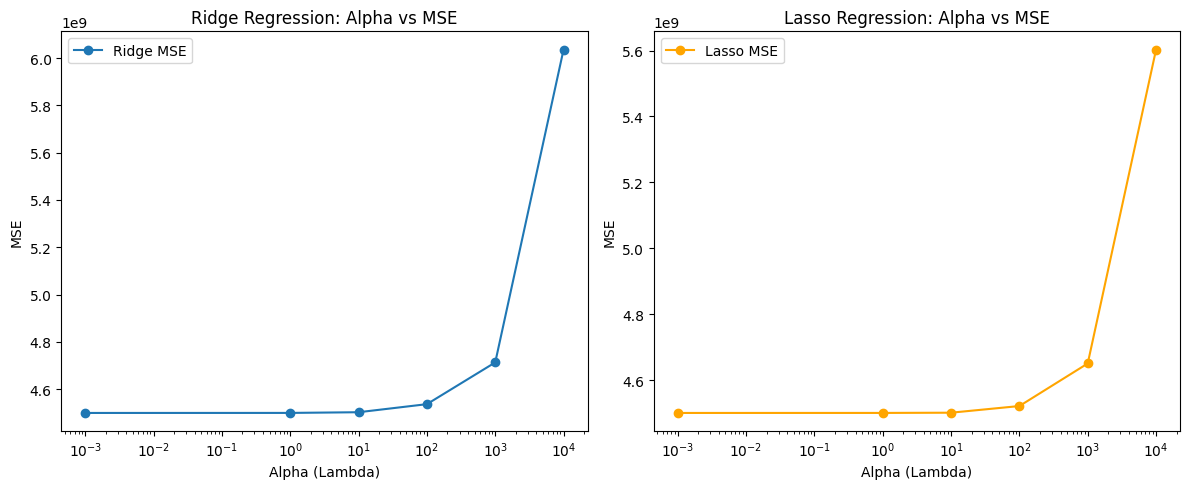

In [ ]:
plt.figure(figsize=(12, 5))

# Ridge
plt.subplot(1, 2, 1)
plt.plot(ridge_alphas, ridge_mses, marker='o', label='Ridge MSE')
plt.xscale('log')
plt.title("Ridge Regression: Alpha vs MSE")
plt.xlabel("Alpha (Lambda)")
plt.ylabel("MSE")
plt.legend()

# Lasso
plt.subplot(1, 2, 2)
plt.plot(lasso_alphas, lasso_mses, marker='o', color='orange', label='Lasso MSE')
plt.xscale('log')
plt.title("Lasso Regression: Alpha vs MSE")
plt.xlabel("Alpha (Lambda)")
plt.ylabel("MSE")
plt.legend()

plt.tight_layout()
plt.show()

### Step 11: Compare Manual vs Scikit-Learn Models
This combines manual and sklearn results. For comparison, it plots MSE and R2 results side by side for all models.

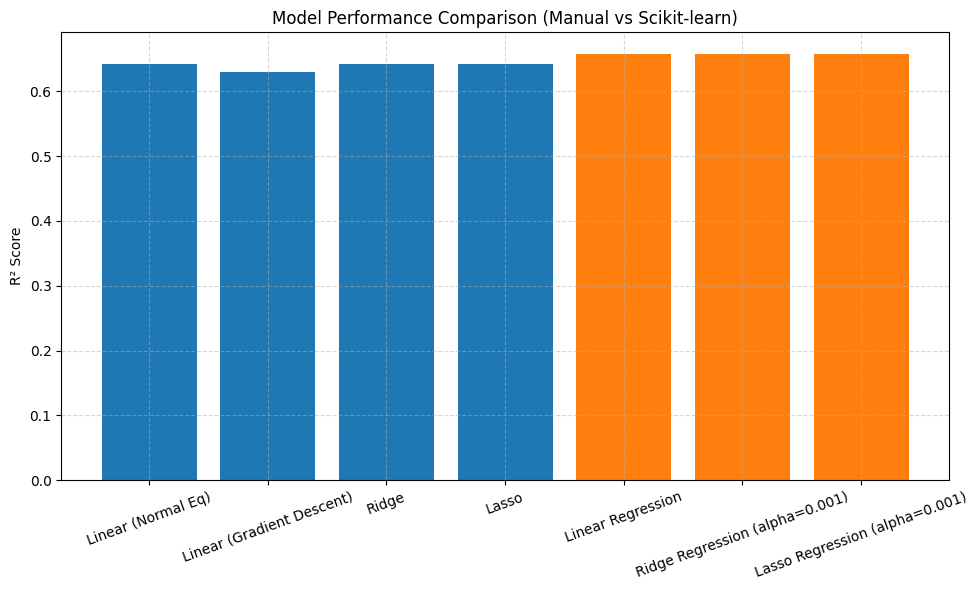

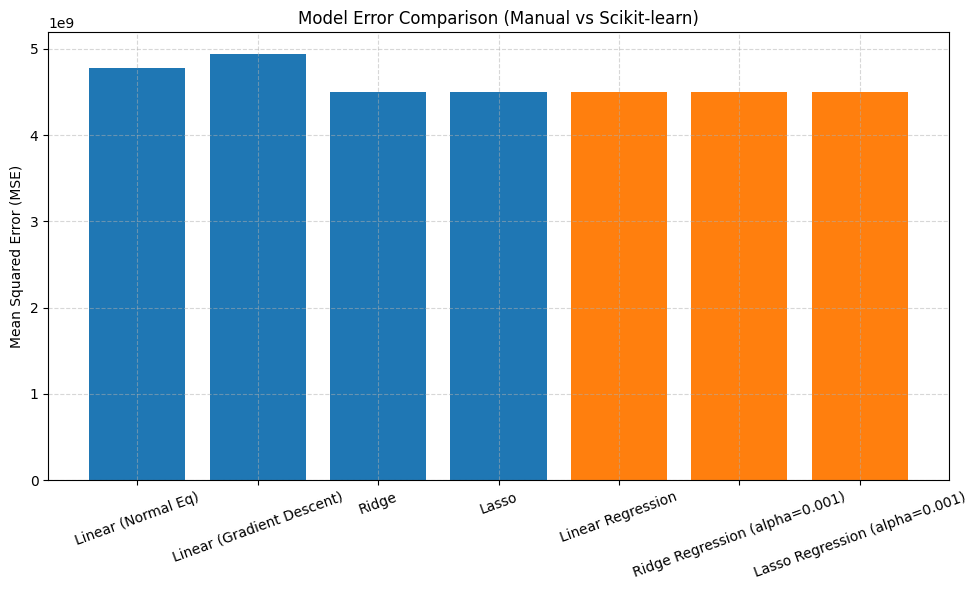

In [ ]:
# --- Manual model results ---
manual_models = ["Linear (Normal Eq)", "Linear (Gradient Descent)", "Ridge", "Lasso"]
manual_mse = [mse_train_linear, mse_train_linear_gd, ridge_mses[2], lasso_mses[2]]
manual_r2 = [r2_train_linear, r2_train_linear_gd, ridge_r2s[2], lasso_r2s[2]]

# --- Scikit-learn model results  ---
sk_models = list(metrics.keys())
sk_mse = [metrics[m]["MSE"] for m in sk_models]
sk_r2 = [metrics[m]["R2"] for m in sk_models]

# --- Combine for single chart ---
plt.figure(figsize=(10, 6))
all_models = manual_models + sk_models
all_mse = manual_mse + sk_mse
all_r2 = manual_r2 + sk_r2
colors = ['#1f77b4'] * len(manual_models) + ['#ff7f0e'] * len(sk_models)

# === Plot R² comparison ===
plt.bar(all_models, all_r2, color=colors)
plt.xticks(rotation=20)
plt.ylabel("R² Score")
plt.title("Model Performance Comparison (Manual vs Scikit-learn)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Plot MSE comparison ===
plt.figure(figsize=(10, 6))
plt.bar(all_models, all_mse, color=colors)
plt.xticks(rotation=20)
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Model Error Comparison (Manual vs Scikit-learn)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




### Step 12: Evaluate Results of manual and sklearn models on the Test Set

In [ ]:
print("Test Set Performance:\n")
test_metrics = {}

for name, model in models.items():
    y_test_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    test_metrics[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}
    
    print(f"The sklearn {name}:")
    print(f"  - MSE: {mse:.4f}")
    print(f"  - RMSE: {rmse:.4f}")
    print(f"  - MAE: {mae:.4f}")
    print(f"  - R²: {r2:.4f}\n")


Test Set Performance:

The sklearn Linear Regression:
  - MSE: 4575074232.4535
  - RMSE: 67639.2950
  - MAE: 49874.6754
  - R²: 0.6570

The sklearn Ridge Regression (alpha=0.001):
  - MSE: 4575073893.6225
  - RMSE: 67639.2925
  - MAE: 49874.6808
  - R²: 0.6570

The sklearn Lasso Regression (alpha=0.001):
  - MSE: 4575074191.8197
  - RMSE: 67639.2947
  - MAE: 49874.6765
  - R²: 0.6570



In [ ]:


#Manual Linear Regression (Normal Equation) ---
y_test_pred_normal = X_test_b @ w_linear_normal
mse_normal = mean_squared_error(y_test, y_test_pred_normal)
mae_normal = mean_absolute_error(y_test, y_test_pred_normal)
r2_normal = r2_score(y_test, y_test_pred_normal)

print("Manual Linear Regression (Normal Eq) on Test Set:")
print(f"  MSE: {mse_normal:.4f}")
print(f"  MAE: {mae_normal:.4f}")
print(f"  R²: {r2_normal:.4f}\n")

#Manual Linear Regression (Gradient Descent) 
y_test_pred_gd = X_test_b @ w_linear_gd
mse_gd = mean_squared_error(y_test, y_test_pred_gd)
mae_gd = mean_absolute_error(y_test, y_test_pred_gd)
r2_gd = r2_score(y_test, y_test_pred_gd)

print("Manual Linear Regression (Gradient Descent) on Test Set:")
print(f"  MSE: {mse_gd:.4f}")
print(f"  MAE: {mae_gd:.4f}")
print(f"  R²: {r2_gd:.4f}\n")

#Manual Ridge Regression (using best alpha from validation) ---
w_ridge_manual = ridge_regression_normal_eq(X_train_b, y_train, best_alpha_ridge)
y_test_pred_ridge = X_test_b @ w_ridge_manual
mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
r2_ridge = r2_score(y_test, y_test_pred_ridge)

print(f"Manual Ridge Regression (alpha={best_alpha_ridge}) on Test Set:")
print(f"  MSE: {mse_ridge:.4f}")
print(f"  MAE: {mae_ridge:.4f}")
print(f"  R²: {r2_ridge:.4f}\n")

#Manual Lasso Regression (using best alpha from validation) ---
w_lasso_manual = lasso_coordinate_descent(X_train_b, y_train, best_alpha_lasso, num_iters=1000)
y_test_pred_lasso = X_test_b @ w_lasso_manual
mse_lasso = mean_squared_error(y_test, y_test_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
r2_lasso = r2_score(y_test, y_test_pred_lasso)

print(f"Manual Lasso Regression (alpha={best_alpha_lasso}) on Test Set:")
print(f"  MSE: {mse_lasso:.4f}")
print(f"  MAE: {mae_lasso:.4f}")
print(f"  R²: {r2_lasso:.4f}")


Manual Linear Regression (Normal Eq) on Test Set:
  MSE: 4575074232.4535
  MAE: 49874.6754
  R²: 0.6570

Manual Linear Regression (Gradient Descent) on Test Set:
  MSE: 4812234565.9581
  MAE: 51906.7721
  R²: 0.6392

Manual Ridge Regression (alpha=0.001) on Test Set:
  MSE: 4575073893.6225
  MAE: 49874.6808
  R²: 0.6570

Manual Lasso Regression (alpha=0.001) on Test Set:
  MSE: 4574942276.0588
  MAE: 49874.4794
  R²: 0.6570


During this project, we implemented Linear Regression manually (Normal Equation & Gradient Descent) and using Sklearn, along with Ridge and Lasso regression for regularization. All models were evaluated on the validation set using MSE, MAE, AND R^2 metrics.

Key Observations:
- The Normal Equation performs a little better than the Gradien Descent having a lower MSEand higher R^2 score.
- Lasso and Ridge Regression reduce overfitting compared to Normal Eq. and Gradient Descent Linear regression.
- Lasso outperforms Ridge slightly indicating that feature selection in this case lead to better predictions.